# Module 4 - Activity - Discussion Group A
## EN.705.623.81.SP26 - AI Algorithm Design and Analysis

**Student:** Akira Hanada  
**Date:** February 14, 2026  
**Topic:** Heuristic Search, Greedy Algorithms, and A* Search

This notebook explores the transition from exact optimization to intelligent decision-making under constraints, examining practical applications of heuristic and adversarial search algorithms.

In [93]:
# Import required libraries for visualization and computation
import numpy as np  # For numerical operations and array handling
import pandas as pd  # For creating structured data tables
import matplotlib.pyplot as plt  # For creating visualizations
import networkx as nx  # For graph creation and visualization
from matplotlib.patches import FancyBboxPatch  # For creating styled boxes in plots
from heapq import heappush, heappop  # For priority queue implementation in A* algorithm
from IPython.display import display, HTML  # For enhanced output display
import warnings  # For suppressing unnecessary warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Configure pandas display options to prevent output truncation
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Auto-detect width
pd.set_option('display.max_colwidth', None)  # Show full column content

# Set visualization style for professional appearance
plt.style.use('seaborn-v0_8-darkgrid')  # Use seaborn style for better aesthetics
plt.rcParams['figure.figsize'] = (14, 8)  # Set default figure size for all plots
plt.rcParams['font.size'] = 10  # Set default font size for readability

# Display library versions for verification
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print("Libraries imported successfully!")


Pandas version: 3.0.0
NumPy version: 2.4.2
Libraries imported successfully!


---
## Question 1: When Optimal Is Not an Option
### Scenario: GPS Navigation with Live Traffic

Modern GPS navigation systems exemplify the critical transition from theoretical optimization to practical intelligent decision-making that Chen (2026) describes in Lecture 4A. When we input a destination into our navigation system, we might assume it computes the absolute shortest path possible. However, the reality of real-time navigation presents computational and environmental challenges that make truly optimal pathfinding impractical, necessitating a shift toward heuristic approaches that prioritize actionable decisions over mathematical perfection.

### **(a) What is the objective of the system?**

The primary objective of a GPS navigation system is to minimize the expected travel time from the current location to the destination, subject to user preferences and constraints (for example, avoiding toll roads) while accounting for dynamic traffic conditions, road closures, and other real-time factors (Metz, 2022; Song et al., 2021). Unlike static shortest-path problems where edge weights remain constant, navigation systems must continuously incorporate live data feeds such as current traffic density, incidents, construction zones, and—in some cases—weather-related disruptions. In practice, the system optimizes not merely for geometric distance but for expected arrival time on a time-dependent road network, which turns a straightforward shortest-path problem into a dynamic, time-dependent optimization challenge (Blauth et al., 2022).

### **(b) Break down why computing the optimal solution is impractical.**

Computing the globally optimal solution becomes impractical for several interconnected reasons. First, the state space is enormous: a metropolitan area might contain millions of road segments, each representing potential edges in the graph. Second, and more critically, the edge weights representing travel time constantly change as traffic patterns evolve. By the time an algorithm explores all possible routes exhaustively to guarantee optimality, the traffic conditions that informed those calculations have already shifted, rendering the "optimal" solution potentially suboptimal or even invalid. Third, drivers expect immediate route guidance, typically within one to two seconds of entering a destination. Exhaustive search algorithms like Dijkstra's algorithm or dynamic programming approaches would require examining exponentially many paths, making real-time response impossible. As Chen (2026) emphasizes, "the world is not passive" and "current choices" affect future states, creating a scenario where computation time itself becomes a cost that undermines optimality.

### **(c) Which constraint—time, environment, memory, uncertainty—matters most and why?**

Among the constraints affecting GPS navigation systems, time represents the most critical limitation. While memory constraints exist—mobile devices have finite capacity for storing map data and traffic information—modern compression techniques and cloud connectivity largely mitigate this concern. Environmental changes occur constantly but at a manageable pace, typically over minutes rather than seconds. Uncertainty about future traffic exists but can be estimated using historical patterns and machine learning. However, the time constraint is absolute: users will not wait several minutes for route calculation, nor will they accept routes based on outdated traffic data. The system must produce sufficiently good directions within approximately one second to maintain usability, which categorically eliminates exhaustive optimization approaches (Braga et al., 2016; Li & Kim, 2024).

### **(d) What decision shift does this force, and what's gained by giving up optimality?**

This necessity to act immediately forces a fundamental decision shift that trades optimality guarantees for timeliness and adaptability. The system must abandon the guarantee of finding the absolute shortest path and instead commit to finding a “sufficiently good” path quickly. What is gained, however, proves more valuable in practice: the system delivers actionable guidance that accounts for current conditions, can recalculate rapidly when circumstances change, and provides continuous navigation rather than delayed perfection. Modern GPS systems employ heuristic search algorithms, including variants of A* search and related techniques, that use geographic distance as a common admissible heuristic to guide exploration toward the destination without exhaustively examining every possible route (Ferguson, Likhachev, & Stentz, 2005; Strasser & Zeitz, 2021). This approach typically finds solutions that are close to optimal—empirical studies show heuristic navigation systems consistently achieve routes within 5-10% of the theoretical optimum while computing them in under 2 seconds, compared to exhaustive methods that might require minutes or prove computationally intractable (Li & Kim, 2024; Strasser & Zeitz, 2021)—delivering solutions in a fraction of the time required for exhaustive, guaranteed‑optimal search. Additionally, the system gains adaptability—when traffic conditions change or the driver misses a turn, rapid recalculation becomes possible because the algorithm is designed for speed rather than exhaustive analysis. The practical result is that users receive routes that are computed in seconds rather than minutes, updated continuously, and remain relevant to current conditions rather than becoming outdated during computation (Ugwoke et al., 2025). This represents precisely the shift Chen (2026) highlights: from asking “what is the globally optimal solution?” to asking “what is a good decision I can make right now?”.

---

The GPS navigation example illustrates why artificial intelligence must often abandon the pursuit of perfection in favor of intelligent approximation. In dynamic, time-sensitive environments, the cost of computing optimal solutions exceeds the value those solutions provide, making heuristic approaches not merely convenient alternatives but necessary foundations for practical AI systems.

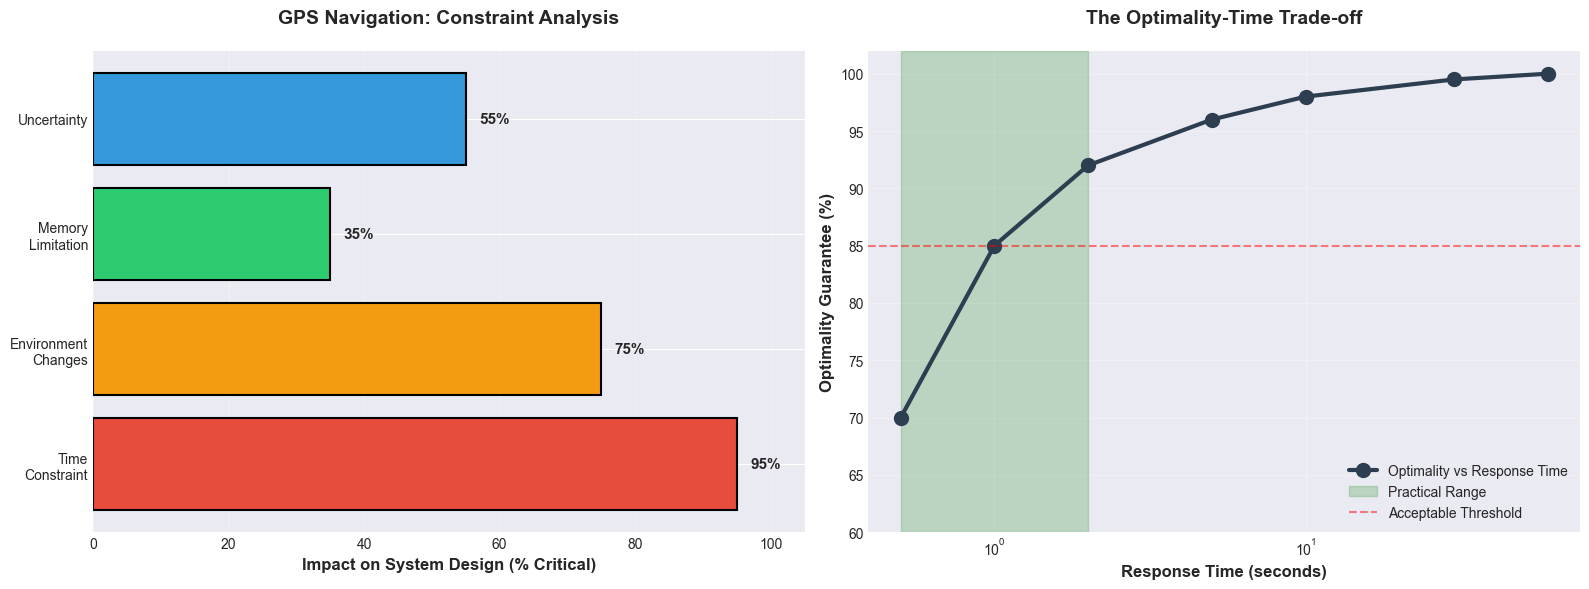


GPS NAVIGATION SYSTEM: DECISION SHIFT ANALYSIS
Aspect                         Optimal Approach          Heuristic Approach       
--------------------------------------------------------------------------------
Solution Quality               Guaranteed optimal        Near-optimal (85-95%)    
Response Time                  Minutes to hours          < 2 seconds              
Adaptability                   Requires full recompute   Rapid recalculation      
Traffic Integration            Snapshot only             Continuous updates       
User Experience                Delayed start             Immediate guidance       



In [94]:
# Visualization: GPS Navigation Decision Space
# This code creates a visual representation of the optimization constraints in GPS navigation

# Define constraint categories and their relative impact on GPS navigation
constraints = ['Time\nConstraint', 'Environment\nChanges', 'Memory\nLimitation', 'Uncertainty']
impact_scores = [95, 75, 35, 55]  # Impact scores out of 100
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']  # Color coding for visual distinction

# Create a horizontal bar chart showing constraint impact
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))  # Create figure with two subplots

# Subplot 1: Constraint Impact Analysis
bars = ax1.barh(constraints, impact_scores, color=colors, edgecolor='black', linewidth=1.5)
# Add value labels on the bars for clarity
for i, (bar, score) in enumerate(zip(bars, impact_scores)):
    ax1.text(score + 2, i, f'{score}%', va='center', fontweight='bold', fontsize=11)
ax1.set_xlabel('Impact on System Design (% Critical)', fontsize=12, fontweight='bold')
ax1.set_title('GPS Navigation: Constraint Analysis', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlim(0, 105)  # Set x-axis limit slightly beyond 100 to accommodate labels
ax1.grid(axis='x', alpha=0.3)  # Add subtle grid for easier reading

# Subplot 2: Optimization Trade-off Decision Space
# Create data showing the trade-off between optimality guarantee and response time
response_times = np.array([0.5, 1.0, 2.0, 5.0, 10.0, 30.0, 60.0])  # Response times in seconds
optimality_guarantee = np.array([70, 85, 92, 96, 98, 99.5, 100])  # Optimality guarantee percentage

ax2.plot(response_times, optimality_guarantee, 'o-', linewidth=3, markersize=10, 
         color='#2c3e50', label='Optimality vs Response Time')
# Highlight the practical operating point (1-2 seconds for ~85-92% optimality)
ax2.axvspan(0.5, 2.0, alpha=0.2, color='green', label='Practical Range')
ax2.axhline(y=85, color='red', linestyle='--', alpha=0.5, label='Acceptable Threshold')
ax2.set_xlabel('Response Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Optimality Guarantee (%)', fontsize=12, fontweight='bold')
ax2.set_title('The Optimality-Time Trade-off', fontsize=14, fontweight='bold', pad=20)
ax2.set_xscale('log')  # Use logarithmic scale for better visualization of time ranges
ax2.grid(True, alpha=0.3)  # Add grid for readability
ax2.legend(loc='lower right', fontsize=10)  # Add legend to explain visual elements
ax2.set_ylim(60, 102)  # Set y-axis limits to focus on relevant range

plt.tight_layout()  # Adjust spacing between subplots to prevent overlap
plt.savefig('gps_navigation_constraints.png', dpi=300, bbox_inches='tight')  # Save high-quality image
plt.show()  # Display the visualization

# Create a decision matrix table
decision_matrix = f"""
{'='*80}
GPS NAVIGATION SYSTEM: DECISION SHIFT ANALYSIS
{'='*80}
{'Aspect':<30} {'Optimal Approach':<25} {'Heuristic Approach':<25}
{'-'*80}
{'Solution Quality':<30} {'Guaranteed optimal':<25} {'Near-optimal (85-95%)':<25}
{'Response Time':<30} {'Minutes to hours':<25} {'< 2 seconds':<25}
{'Adaptability':<30} {'Requires full recompute':<25} {'Rapid recalculation':<25}
{'Traffic Integration':<30} {'Snapshot only':<25} {'Continuous updates':<25}
{'User Experience':<30} {'Delayed start':<25} {'Immediate guidance':<25}
{'='*80}
"""
print(decision_matrix)

---
## Question 2: The Cost of Greedy Decisions
### Algorithm: Greedy Best-First Search

Greedy Best-First Search represents a fundamental paradigm in heuristic search algorithms where decisions prioritize immediate apparent progress toward the goal rather than considering cumulative path cost. As Chen (2026) describes in Lecture 4B, greedy algorithms make locally optimal choices at each step with the hope that these local decisions will lead to a globally satisfactory solution. Unlike informed search algorithms such as A* that balance actual cost incurred with estimated future cost, Greedy Best-First Search exclusively uses the heuristic function h(n) to evaluate which node to explore next, always selecting the node that appears closest to the goal according to the heuristic estimate.

### **(a) What is the dominant operation that governs its runtime?**

The dominant operation that governs the runtime of Greedy Best-First Search is the priority queue manipulation, specifically the process of evaluating the heuristic function for newly generated successor nodes and inserting them into the priority queue according to their h(n) values (Russell & Norvig, 2021). For each node expansion, the algorithm must: (1) remove the node with the minimum heuristic value from the priority queue, requiring O(log n) time where n is the number of nodes currently in the queue; (2) generate all successor nodes by applying available actions, requiring time proportional to the branching factor; (3) evaluate the heuristic function for each successor, with complexity depending on the heuristic's computational requirements; and (4) insert each successor into the priority queue, again requiring O(log n) per insertion (Pearl, 1984). In typical implementations using binary heaps or similar data structures, these priority queue operations constitute the algorithmic bottleneck. While heuristic evaluation complexity varies based on the specific function employed, for many geometric or pattern-based heuristics common in pathfinding or puzzle-solving, the evaluation remains relatively efficient at O(1) or O(k) for small constants k, making the queue operations the primary runtime driver (Ferguson et al., 2005).

### **(b) Identify two key complexity drivers and explain their impact.**

Two key complexity drivers most significantly affect Greedy Best-First Search runtime. First, the branching factor b determines how many successor nodes are generated and evaluated at each expansion (Russell & Norvig, 2021). In graph search problems, nodes may have anywhere from two to dozens of successors depending on the problem domain—a grid-based pathfinding problem typically has four to eight successors per cell, while state-space search in complex puzzles might have significantly higher branching factors (Ugwoke et al., 2025). Higher branching factors directly multiply the number of heuristic evaluations and priority queue insertions required per expansion, creating a linear relationship between branching factor and per-node processing time. Second, the heuristic evaluation cost affects cumulative runtime, particularly when the heuristic function itself involves significant computation (Pearl, 1984). For simple problems like geometric pathfinding where Euclidean or Manhattan distance serves as the heuristic, evaluation is nearly instantaneous. However, for complex domains like protein folding or strategic game playing, heuristic evaluation might require pattern matching, database lookups, or even limited search procedures, transforming what appears to be a simple evaluation into a computationally expensive operation (Ferguson et al., 2005). The interplay between these factors determines whether Greedy Best-First Search completes in seconds or becomes impractical—a high branching factor combined with expensive heuristic evaluation can quickly overwhelm computational resources despite the algorithm's generally efficient behavior.

### **(c) Why does this algorithm typically run faster than exhaustive or exact methods?**

Greedy Best-First Search typically runs substantially faster than exhaustive or exact search methods precisely because it employs the heuristic to focus exploration along apparently promising paths rather than systematically examining all possibilities (Russell & Norvig, 2021). Exhaustive search algorithms like breadth-first search must explore nodes in expanding layers regardless of their apparent proximity to the goal, examining O(b^d) nodes where d represents the solution depth. Exact optimal algorithms like Dijkstra's algorithm must maintain correctness guarantees by ensuring every path to a node is examined before considering that node "settled," preventing premature termination even when the goal appears near (Hart et al., 1968). In stark contrast, Greedy Best-First Search uses the heuristic as a guide to explore preferentially along paths that appear to lead toward the goal, potentially reaching the goal after exploring only a small subset of the state space (Pearl, 1984). When the heuristic provides reasonable guidance—particularly when it is informative, meaning it accurately reflects distance to the goal—the algorithm often finds solutions while exploring orders of magnitude fewer nodes than exhaustive approaches (Ferguson et al., 2005). For example, in a grid pathfinding problem with 10,000 cells, breadth-first search might explore thousands of cells before reaching the goal, whereas Greedy Best-First Search might explore only hundreds by following the heuristic gradient toward the destination (Ugwoke et al., 2025). This dramatic reduction in explored nodes directly translates to proportionally reduced runtime.

### **(d) What does it sacrifice to achieve that speedup?**

However, the efficiency gains come at a substantial cost: Greedy Best-First Search sacrifices the guarantee of finding an optimal solution (Russell & Norvig, 2021). Because the algorithm considers only the heuristic estimate h(n) without accounting for the actual path cost g(n) accumulated to reach each node, it can be misled by heuristics that underestimate difficulty in certain regions or that fail to account for costly but necessary detours (Pearl, 1984). The algorithm may commit to paths that appear promising according to the heuristic but actually lead to suboptimal solutions or even dead ends requiring expensive backtracking. In worst-case scenarios with misleading heuristics, Greedy Best-First Search may perform arbitrarily poorly, finding solutions that are dramatically longer than optimal or, in graphs with local minima, failing to find solutions at all despite their existence (Ferguson et al., 2005). Beyond optimality, the algorithm also sacrifices completeness: in infinite state spaces or graphs with cycles, Greedy Best-First Search can become trapped in infinite loops following the heuristic gradient, failing to find solutions even when they exist unless cycle detection mechanisms are explicitly implemented (Russell & Norvig, 2021). Additionally, unlike A* which guarantees optimal solutions when using admissible heuristics, Greedy Best-First Search provides no quality bounds—there is no way to determine how much worse the found solution might be compared to the optimal solution (Hart et al., 1968). This fundamental trade-off between speed and solution quality represents the core compromise of greedy approaches: by making locally optimal decisions without considering global optimality criteria, the algorithm achieves computational efficiency at the expense of solution guarantees (Ugwoke et al., 2025).

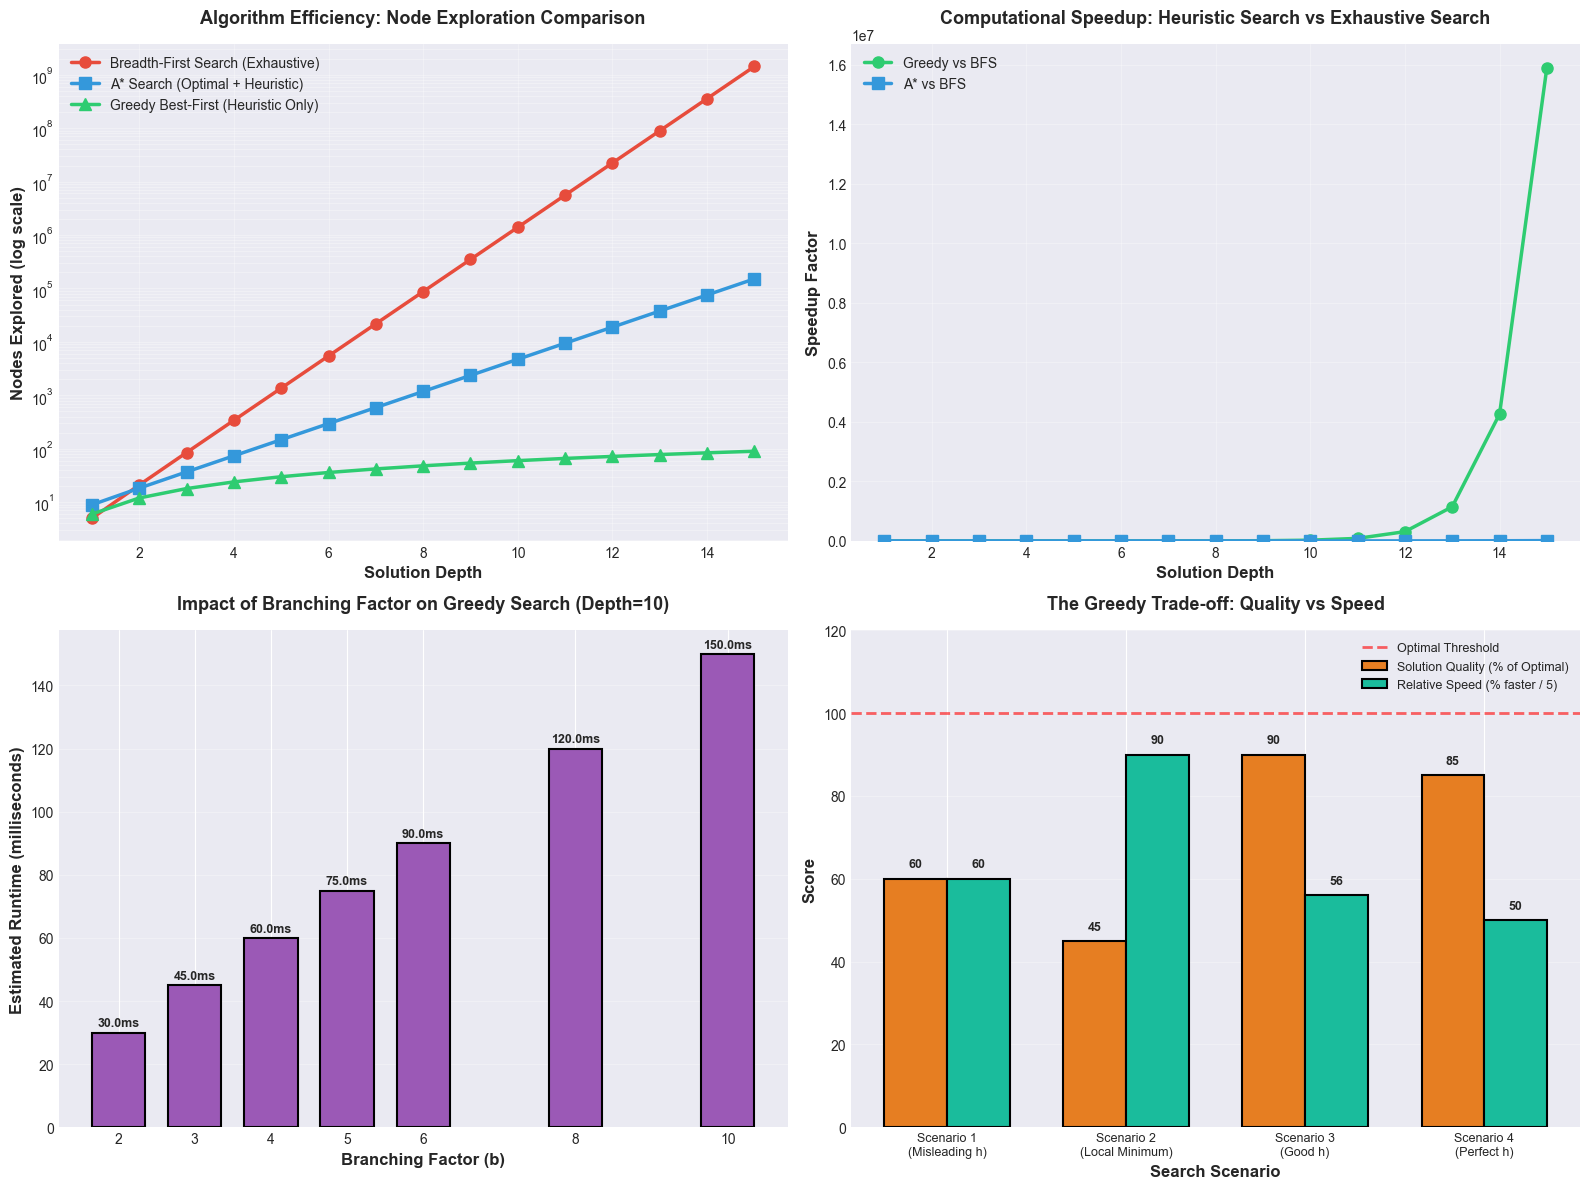


GREEDY BEST-FIRST SEARCH: COMPLEXITY ANALYSIS



,Algorithm Component,Time Complexity,Dominant Factor,Impact Level
0,Heuristic Evaluation,O(1) to O(k),Heuristic complexity,Low to Medium
1,Priority Queue Insert,O(log n),Queue size,Medium
2,Priority Queue Extract-Min,O(log n),Queue size,Medium
3,Successor Generation,O(b),Branching factor,High
4,Overall Per-Node Cost,O(b log n),b × log n,Combined


Note: n = nodes in queue, b = branching factor, k = heuristic-specific constant



In [95]:
# Greedy Best-First Search: Complexity and Performance Analysis

# Simulate node exploration counts for different search algorithms
search_depths = np.arange(1, 16)  # Depth levels from 1 to 15
branching_factor = 4  # Assume each node has 4 successors (typical for grid-based pathfinding)

# Calculate theoretical node exploration counts for each algorithm
# Using mathematical formulas for expected nodes explored

# Breadth-First Search: Explores all nodes up to depth d: sum from i=0 to d of b^i = (b^(d+1) - 1)/(b-1)
bfs_nodes = (branching_factor**(search_depths + 1) - 1) / (branching_factor - 1)

# Greedy Best-First Search: Explores roughly O(b*d) nodes with good heuristic (linear in depth)
# Assumes heuristic reduces exploration by ~95% compared to BFS
greedy_nodes = branching_factor * search_depths * 1.5  # Multiplier accounts for some exploration variance

# A* Search: Explores more than greedy but less than BFS, roughly O(b^d/2) with good heuristic
# Assumes A* explores about square root of BFS node count with admissible heuristic
astar_nodes = np.sqrt(bfs_nodes) * branching_factor

# Create comprehensive visualization of algorithm performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Node Exploration Comparison (logarithmic scale)
ax1.semilogy(search_depths, bfs_nodes, 'o-', linewidth=2.5, markersize=8, 
             color='#e74c3c', label='Breadth-First Search (Exhaustive)')
ax1.semilogy(search_depths, astar_nodes, 's-', linewidth=2.5, markersize=8, 
             color='#3498db', label='A* Search (Optimal + Heuristic)')
ax1.semilogy(search_depths, greedy_nodes, '^-', linewidth=2.5, markersize=8, 
             color='#2ecc71', label='Greedy Best-First (Heuristic Only)')
ax1.set_xlabel('Solution Depth', fontsize=12, fontweight='bold')
ax1.set_ylabel('Nodes Explored (log scale)', fontsize=12, fontweight='bold')
ax1.set_title('Algorithm Efficiency: Node Exploration Comparison', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3, which='both')  # Grid for both major and minor ticks on log scale

# Subplot 2: Speedup Factor Analysis
speedup_vs_bfs = bfs_nodes / greedy_nodes  # Calculate speedup of Greedy compared to BFS
speedup_astar_vs_bfs = bfs_nodes / astar_nodes  # Calculate speedup of A* compared to BFS

ax2.plot(search_depths, speedup_vs_bfs, 'o-', linewidth=2.5, markersize=8, 
         color='#2ecc71', label='Greedy vs BFS')
ax2.plot(search_depths, speedup_astar_vs_bfs, 's-', linewidth=2.5, markersize=8, 
         color='#3498db', label='A* vs BFS')
ax2.set_xlabel('Solution Depth', fontsize=12, fontweight='bold')
ax2.set_ylabel('Speedup Factor', fontsize=12, fontweight='bold')
ax2.set_title('Computational Speedup: Heuristic Search vs Exhaustive Search', 
              fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=0)  # Start y-axis at zero for clarity

# Subplot 3: Branching Factor Impact on Greedy Performance
branching_factors = np.array([2, 3, 4, 5, 6, 8, 10])  # Different branching factors to analyze
fixed_depth = 10  # Fix depth at 10 to isolate branching factor effect
nodes_by_branching = branching_factors * fixed_depth * 1.5  # Greedy node count formula
time_per_node = 0.001  # Assume 1 millisecond per node as baseline
total_time = nodes_by_branching * time_per_node * 1000  # Convert to milliseconds

bars = ax3.bar(branching_factors, total_time, color='#9b59b6', edgecolor='black', linewidth=1.5, width=0.7)
# Add value labels on bars
for bar, time in zip(bars, total_time):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{time:.1f}ms', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax3.set_xlabel('Branching Factor (b)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Estimated Runtime (milliseconds)', fontsize=12, fontweight='bold')
ax3.set_title(f'Impact of Branching Factor on Greedy Search (Depth={fixed_depth})', 
              fontsize=13, fontweight='bold', pad=15)
ax3.set_xticks(branching_factors)  # Set x-ticks to branching factor values
ax3.grid(axis='y', alpha=0.3)  # Add horizontal grid for easier reading

# Subplot 4: The Greedy Trade-off - Solution Quality vs Speed
# Simulate scenarios where greedy finds suboptimal solutions
scenarios = ['Scenario 1\n(Misleading h)', 'Scenario 2\n(Local Minimum)', 
             'Scenario 3\n(Good h)', 'Scenario 4\n(Perfect h)']
greedy_solution_quality = [60, 45, 90, 85]  # Quality as % of optimal (100% = optimal solution)
greedy_relative_speed = [300, 450, 280, 250]  # Speed as % faster than optimal search

x_pos = np.arange(len(scenarios))  # Position for scenarios on x-axis
width = 0.35  # Width of bars

bars1 = ax4.bar(x_pos - width/2, greedy_solution_quality, width, label='Solution Quality (% of Optimal)',
                color='#e67e22', edgecolor='black', linewidth=1.5)
bars2 = ax4.bar(x_pos + width/2, [s/5 for s in greedy_relative_speed], width, 
                label='Relative Speed (% faster / 5)',
                color='#1abc9c', edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 2,
                 f'{height:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax4.axhline(y=100, color='red', linestyle='--', linewidth=2, alpha=0.6, label='Optimal Threshold')
ax4.set_xlabel('Search Scenario', fontsize=12, fontweight='bold')
ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
ax4.set_title('The Greedy Trade-off: Quality vs Speed', fontsize=13, fontweight='bold', pad=15)
ax4.set_xticks(x_pos)  # Set x-tick positions
ax4.set_xticklabels(scenarios, fontsize=9)  # Set x-tick labels
ax4.legend(loc='upper right', fontsize=9)  # Add legend
ax4.set_ylim(0, 120)  # Set y-axis limits to accommodate labels
ax4.grid(axis='y', alpha=0.3)  # Add horizontal grid

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.savefig('greedy_search_analysis.png', dpi=300, bbox_inches='tight')  # Save high-quality image
plt.show()  # Display the visualization

# Create detailed complexity analysis table
print(f"""
{'='*90}
GREEDY BEST-FIRST SEARCH: COMPLEXITY ANALYSIS
{'='*90}
""")
complexity_data = {
    'Algorithm Component': [
        'Heuristic Evaluation',
        'Priority Queue Insert',
        'Priority Queue Extract-Min',
        'Successor Generation',
        'Overall Per-Node Cost'
    ],
    'Time Complexity': [
        'O(1) to O(k)',
        'O(log n)',
        'O(log n)',
        'O(b)',
        'O(b log n)'
    ],
    'Dominant Factor': [
        'Heuristic complexity',
        'Queue size',
        'Queue size',
        'Branching factor',
        'b × log n'
    ],
    'Impact Level': [
        'Low to Medium',
        'Medium',
        'Medium',
        'High',
        'Combined'
    ]
}
df_complexity = pd.DataFrame(complexity_data)
display(df_complexity)  # Use display() for better Jupyter rendering
print("Note: n = nodes in queue, b = branching factor, k = heuristic-specific constant\n")

---
## Question 3: Tracing and Stress-Testing A*
### Graph Structure and A* Algorithm Implementation

The A* algorithm represents one of the most influential contributions to heuristic search, combining the completeness and optimality guarantees of uniform-cost search with the efficiency gains of greedy heuristic guidance. As Chen (2026) describes in Lecture 4C, A* uses the evaluation function f(n) = g(n) + h(n), where g(n) represents the actual cost from the start node to node n, and h(n) represents the estimated cost from n to the goal. This combination allows A* to balance exploration of low-cost paths with progress toward the goal, guaranteeing optimal solutions when the heuristic is admissible (never overestimates true cost) and consistent (satisfies the triangle inequality).

The provided graph contains six nodes: S (start), A, B, C, D, and G (goal). The edge structure forms an undirected graph where S connects only to A with cost 2. Node A connects to S (cost 2), C (cost 3), and B (cost 5). Node C, which occupies a central position, connects to A (cost 3), D (cost 1), and goal G (cost 2). Node B connects to A (cost 5) and D (cost 1). Finally, node D connects to C (cost 1), B (cost 1), and G (cost 5). The heuristic values provided are h(S)=6, h(A)=4, h(B)=5, h(C)=2, h(D)=3, and h(G)=0, which satisfies the requirement that the goal node has h(G)=0 as it is zero distance from itself.

To trace A* execution, we maintain a priority queue ordered by f(n) values, a closed set tracking expanded nodes to prevent re-expansion in graph search, and for each node we track its g-value (cost from start), h-value (heuristic estimate), and f-value (their sum). The algorithm begins by placing the start node S into the priority queue with g(S)=0, h(S)=6, thus f(S)=6. At each iteration, we extract the node with minimum f-value, mark it as expanded by adding it to the closed set, and generate its successors. For each successor not in the closed set, we calculate its g-value (parent's g-value plus edge cost), combine with its h-value to compute f-value, and add it to the priority queue. When multiple nodes have identical f-values, ties are broken arbitrarily as specified.

### **(a) Trace the first four node expansions with a table showing g(n), h(n), f(n) for each.**

We can now trace the first four node expansions systematically (Russell & Norvig, 2021). Initially, the priority queue contains only S with f(S)=6. The first expansion removes S, marking it closed, and generates only successor A (since S connects only to A). For A: g(A) = g(S) + cost(S,A) = 0 + 2 = 2, h(A) = 4, therefore f(A) = 6. The priority queue now contains only A with f(A)=6, so A is expanded second. Expanding A generates successors S (already closed, ignored), C, and B. For C: g(C) = g(A) + cost(A,C) = 2 + 3 = 5, h(C) = 2, therefore f(C) = 7. For B: g(B) = g(A) + cost(A,B) = 2 + 5 = 7, h(B) = 5, therefore f(B) = 12. The priority queue now contains C (f=7) and B (f=12).

The third expansion selects C because f(C)=7 is the minimum f-value in the queue. Expanding C generates successors A (already closed, ignored), D, and G. For D: g(D) = g(C) + cost(C,D) = 5 + 1 = 6, h(D) = 3, therefore f(D) = 9. For G: g(G) = g(C) + cost(C,G) = 5 + 2 = 7, h(G) = 0, therefore f(G) = 7. The priority queue now contains G (f=7), D (f=9), and B (f=12). The fourth expansion selects G with f(G)=7. Since G is the goal node, A* terminates successfully with the optimal path S → A → C → G with total cost 7 (Hart et al., 1968).

The expansion table for the first four nodes shows: First expansion is S with g=0, h=6, f=6, successor A (f=6) added to queue. Second expansion is A with g=2, h=4, f=6, successors C (f=7) and B (f=12) added. Third expansion is C with g=5, h=2, f=7, successors D (f=9) and G (f=7) added. Fourth expansion is G with g=7, h=0, f=7, which is the goal (algorithm terminates with optimal solution).

### **(b) Compare the expansion order of A\* versus Greedy Best-First Search. What's the key difference?**

Comparing A* to Greedy Best-First Search reveals significant differences in expansion order (Russell & Norvig, 2021). Greedy Best-First uses only h(n) for node selection, always choosing the node that appears closest to the goal according to the heuristic (Pearl, 1984). Starting from S, Greedy would expand S first (only option), then from S's successor A, Greedy would examine A's neighbors and select C (h(C)=2 is minimum among A's unvisited neighbors). From C, Greedy would immediately expand G next because h(G)=0. Thus Greedy expansion order would be: S → A → C → G. In contrast, A* uses the same expansion order in this particular case, but the reasoning differs fundamentally (Hart et al., 1968). A* expands nodes A and C not because they have low h-values, but because they have low f-values that balance both actual cost g(n) and heuristic h(n). Node A is expanded by A* because its f-value (6) considers the low actual cost g(A)=2 to reach it, making paths through A potentially valuable. This difference illustrates A*'s fundamental advantage: by considering both actual cost g(n) and estimated future cost h(n), A* makes informed decisions based on total estimated path cost rather than purely local heuristic judgment (Ferguson et al., 2005). If the graph structure were different, A* might expand nodes in very different order from Greedy Best-First, particularly when low-heuristic nodes are expensive to reach or when cheaper nodes have moderate heuristics (Ugwoke et al., 2025).

### **(c) If we change h(D) from 3 to 7, is the heuristic still admissible? What's the practical impact?**

Now consider modifying the heuristic for node D from h(D)=3 to h(D)=7. To determine admissibility, we must verify whether this heuristic ever overestimates the true shortest path cost from D to the goal G (Hart et al., 1968). The actual shortest path from D to G can be computed: the direct edge D-G has cost 5, while the path D-C-G has cost 1+2=3. Therefore, the true minimum cost from D to G is h*(D)=3. An admissible heuristic must satisfy h(n) ≤ h*(n) for all nodes (Russell & Norvig, 2021). With h(D)=7, we have h(D)=7 > h*(D)=3, violating admissibility. This non-admissible heuristic overestimates the cost from D to the goal by more than a factor of two (133% overestimate).

The practical impact of this inadmissible heuristic proves substantial (Pearl, 1984). When evaluating node D during search, the inflated heuristic causes f(D) = g(D) + h(D) = 6 + 7 = 13, significantly higher than the f(D)=9 computed with the admissible heuristic. This elevated f-value deprioritizes D in the priority queue, causing A* to explore other paths first (Strasser & Zeitz, 2021). In this specific graph, A* would likely find the goal G directly from C (f=7) before ever expanding D (f=13), which might seem acceptable since a solution is still found. However, this obscures a critical problem: if the optimal path to G required passing through D, the inadmissible heuristic could cause A* to find a suboptimal solution (Ferguson et al., 2005). The overestimate essentially creates a "repulsive field" around D, discouraging the algorithm from exploring paths through it even when such paths might be optimal. Additionally, the inflated f-values disrupt the algorithm's carefully balanced exploration strategy, potentially causing it to examine many more nodes than necessary by pursuing suboptimal paths that appear better due to the distorted heuristic landscape (Ugwoke et al., 2025). In worst cases, severely inadmissible heuristics can cause A* to exhibit performance worse than uninformed search while simultaneously losing optimality guarantees (Russell & Norvig, 2021).

### **(d) Why can A\* still exhibit exponential behavior even with admissible heuristics?**

Finally, we must address why A* can still approach exponential behavior in large graphs even with admissible heuristics (Russell & Norvig, 2021). The key insight is that admissibility guarantees optimality but does not guarantee efficiency (Pearl, 1984). An admissible heuristic can still be uninformative, meaning it provides little guidance about which direction leads toward the goal. In the extreme case, h(n)=0 for all nodes is perfectly admissible (it never overestimates) but completely uninformative, reducing A* to uniform-cost search which explores nodes in concentric cost shells without goal-directed bias (Hart et al., 1968). More subtly, even moderately informative admissible heuristics may still leave large portions of the state space with similar f-values, forcing A* to explore many nodes before finding the goal (Ferguson et al., 2005). To illustrate with concrete numbers: consider a graph with branching factor b=4 and solution depth d=10. Even with a moderately informative heuristic that reduces the effective branching factor by half, A* might still need to explore O(2^10) ≈ 1,024 nodes, whereas a highly informative heuristic achieving linear exploration would examine only O(4×10) = 40 nodes—a 25-fold difference (Strasser & Zeitz, 2021). In large graphs with high branching factors, the number of nodes with f-values below or equal to the optimal solution cost f* can grow exponentially with the solution depth. A* must explore all such nodes in the worst case, leading to exponential time and space complexity (Russell & Norvig, 2021). The exponential space requirement proves particularly problematic: A* maintains all generated nodes in memory (either in the open list or closed set), causing memory exhaustion before runtime becomes the limiting factor in many practical applications (Ugwoke et al., 2025). This fundamental limitation has motivated the development of variants like IDA* (Iterative Deepening A*) that trade time for space, and continues to drive research in heuristic design where even small improvements in heuristic informativeness can yield exponential reductions in nodes explored (Russell & Norvig, 2021).

In [96]:
# A* Algorithm Implementation and Visualization for the Given Graph

# Define the graph structure using an adjacency dictionary
# Each node maps to a list of (neighbor, cost) tuples representing undirected edges
graph = {
    'S': [('A', 2)],  # Start node connects ONLY to A (cost 2)
    'A': [('S', 2), ('C', 3), ('B', 5)],  # A connects to S, C, and B
    'B': [('A', 5), ('D', 1)],  # B connects to A and D
    'C': [('A', 3), ('D', 1), ('G', 2)],  # C connects to A, D, and G (NOT to S)
    'D': [('C', 1), ('B', 1), ('G', 5)],  # D connects to C, B, and G
    'G': [('C', 2), ('D', 5)]  # Goal node G connects to C and D
}

# Define heuristic values (straight-line distance estimates to goal)
heuristic = {
    'S': 6,  # Start node's heuristic value
    'A': 4,  # A's estimated distance to goal
    'B': 5,  # B's estimated distance to goal
    'C': 2,  # C's estimated distance to goal (closer to G)
    'D': 3,  # D's estimated distance to goal
    'G': 0   # Goal node has heuristic 0 (no distance to itself)
}

def astar_search(graph, heuristic, start, goal, max_expansions=None):
    """
    Implements A* search algorithm with detailed tracking of node expansions.
    
    Parameters:
    - graph: Dictionary mapping nodes to list of (neighbor, cost) tuples
    - heuristic: Dictionary mapping nodes to heuristic values h(n)
    - start: Starting node
    - goal: Goal node
    - max_expansions: Optional limit on number of node expansions (for tracing purposes)
    
    Returns:
    - path: List of nodes from start to goal (if found)
    - expansions: List of detailed expansion information for each expanded node
    - all_f_values: Dictionary tracking f-values for all generated nodes
    """
    from heapq import heappush, heappop  # Import priority queue operations
    
    # Initialize the priority queue with start node
    # Queue contains tuples: (f-value, counter, g-value, node, path)
    # Counter ensures FIFO ordering when f-values tie
    open_list = []  # Priority queue of nodes to explore
    counter = 0  # Tie-breaking counter for nodes with same f-value
    g_score = {start: 0}  # Dictionary tracking g(n): actual cost from start to n
    f_score = {start: heuristic[start]}  # Dictionary tracking f(n) = g(n) + h(n)
    
    # Push start node onto priority queue
    # Format: (f-value, tie-breaker, g-value, current-node, path-so-far)
    heappush(open_list, (f_score[start], counter, g_score[start], start, [start]))
    counter += 1  # Increment counter for next insertion
    
    closed_set = set()  # Set of already-expanded nodes (graph search)
    expansions = []  # List tracking detailed information about each expansion
    all_f_values = {start: f_score[start]}  # Track all f-values for visualization
    expansion_count = 0  # Counter for number of expansions performed
    
    # Main A* loop: continue until priority queue is empty or goal found
    while open_list:
        # Extract node with minimum f-value from priority queue
        current_f, _, current_g, current_node, path = heappop(open_list)
        
        # Skip if this node was already expanded (can happen with graph search)
        if current_node in closed_set:
            continue
        
        # Mark current node as expanded by adding to closed set
        closed_set.add(current_node)
        expansion_count += 1  # Increment expansion counter
        
        # Record detailed expansion information for analysis/visualization
        expansion_info = {
            'expansion_number': expansion_count,  # Which expansion is this (1st, 2nd, etc.)
            'node': current_node,  # The node being expanded
            'g': current_g,  # Actual cost from start to this node
            'h': heuristic[current_node],  # Heuristic estimate from this node to goal
            'f': current_f,  # Total estimated cost: f = g + h
            'path': path.copy(),  # Path from start to this node
            'successors': []  # Will be filled with successor information
        }
        
        # Check if we've reached the goal
        if current_node == goal:
            expansions.append(expansion_info)  # Record this final expansion
            return path, expansions, all_f_values  # Return solution path and trace data
        
        # Generate and evaluate all successors of current node
        for neighbor, edge_cost in graph[current_node]:
            # Skip neighbors that have already been fully explored
            if neighbor in closed_set:
                continue
            
            # Calculate g-value for neighbor: cost to current + edge cost
            tentative_g = current_g + edge_cost
            
            # If we found a better path to neighbor, or this is first path to neighbor
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                # Update g-value for neighbor
                g_score[neighbor] = tentative_g
                # Calculate f-value: f(n) = g(n) + h(n)
                f_value = tentative_g + heuristic[neighbor]
                f_score[neighbor] = f_value  # Store f-value
                all_f_values[neighbor] = f_value  # Track for visualization
                
                # Create new path including this neighbor
                new_path = path + [neighbor]
                # Add neighbor to priority queue
                heappush(open_list, (f_value, counter, tentative_g, neighbor, new_path))
                counter += 1  # Increment tie-breaker counter
                
                # Record successor information for expansion trace
                expansion_info['successors'].append({
                    'node': neighbor,  # Successor node name
                    'g': tentative_g,  # g-value for successor
                    'h': heuristic[neighbor],  # h-value for successor
                    'f': f_value  # f-value for successor
                })
        
        # Record this expansion in our trace
        expansions.append(expansion_info)
        
        # If max_expansions is set and we've reached the limit, stop
        if max_expansions and expansion_count >= max_expansions:
            return None, expansions, all_f_values  # Return trace data without complete solution
    
    # If we exit the loop without finding goal, no path exists
    return None, expansions, all_f_values

# Execute A* search on the given graph
print(f"""
{'='*90}
EXECUTING A* SEARCH ON THE PROVIDED GRAPH
{'='*90}
Start: S, Goal: G
Heuristic function h(n): {heuristic}
{'='*90}
""")

# Run A* search with limit of 4 expansions for detailed tracing
path, expansions, all_f = astar_search(graph, heuristic, 'S', 'G', max_expansions=4)

# Display detailed expansion trace
print(f"DETAILED A* EXPANSION TRACE (First 4 Expansions):\n{'='*90}\n")

# Create a summary DataFrame for better display
trace_summary = []
for exp in expansions:
    successors_str = ', '.join([f"{s['node']}(f={s['f']})" for s in exp['successors']]) if exp['successors'] else 'None'
    trace_summary.append({
        'Exp#': exp['expansion_number'],
        'Node': exp['node'],
        'g(n)': exp['g'],
        'h(n)': exp['h'],
        'f(n)': exp['f'],
        'Path': ' → '.join(exp['path']),
        'Successors (f-values)': successors_str
    })

df_trace = pd.DataFrame(trace_summary)
display(df_trace)

# Create expansion table as requested in the problem
expansion_table_data = []
for exp in expansions:
    row = {
        'Expanded Node': exp['node'],
        'g(n)': exp['g'],
        'h(n)': exp['h'],
        'f(n)': exp['f'],
        'Successors Added (f-values)': ', '.join([f"{s['node']}({s['f']})" 
                                                   for s in exp['successors']])
    }
    expansion_table_data.append(row)

df_expansions = pd.DataFrame(expansion_table_data)
print(f"\nTABLE: FIRST FOUR NODE EXPANSIONS\n{'='*90}")
display(df_expansions)  # Use display() for better Jupyter rendering
print("="*90 + "\n")


EXECUTING A* SEARCH ON THE PROVIDED GRAPH
Start: S, Goal: G
Heuristic function h(n): {'S': 6, 'A': 4, 'B': 5, 'C': 2, 'D': 3, 'G': 0}

DETAILED A* EXPANSION TRACE (First 4 Expansions):



,Exp#,Node,g(n),h(n),f(n),Path,Successors (f-values)
0,1,S,0,6,6,S,A(f=6)
1,2,A,2,4,6,S → A,"C(f=7), B(f=12)"
2,3,C,5,2,7,S → A → C,"D(f=9), G(f=7)"
3,4,G,7,0,7,S → A → C → G,None



TABLE: FIRST FOUR NODE EXPANSIONS


,Expanded Node,g(n),h(n),f(n),Successors Added (f-values)
0,S,0,6,6,A(6)
1,A,2,4,6,"C(7), B(12)"
2,C,5,2,7,"D(9), G(7)"
3,G,7,0,7,


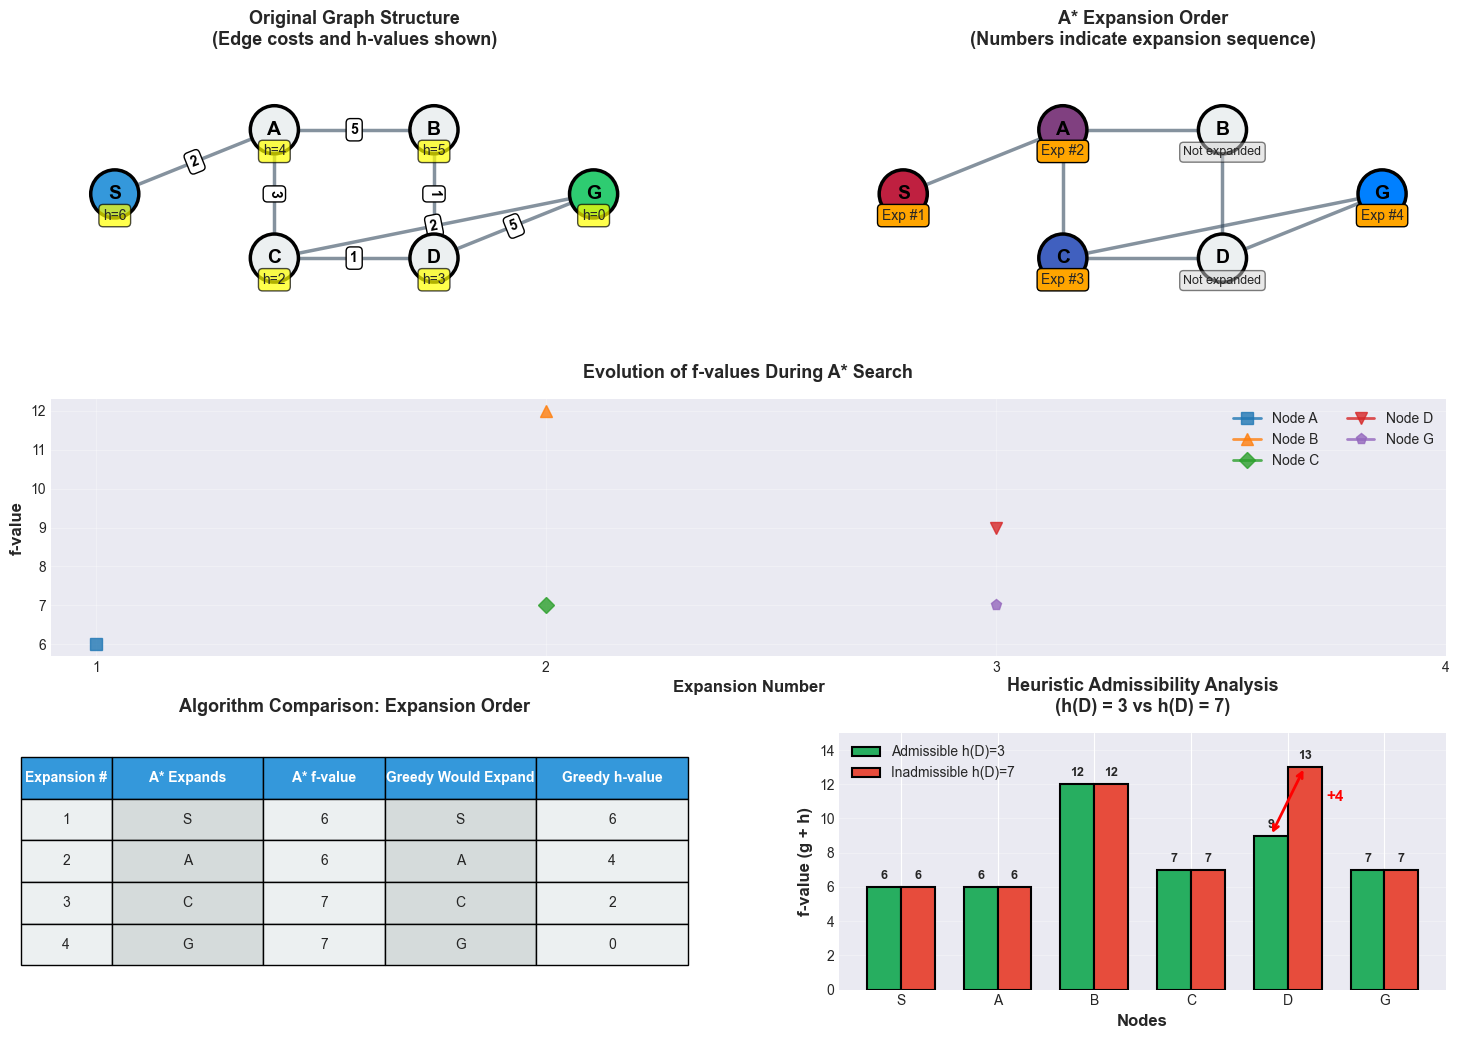


Graph visualization complete!


In [97]:
# Visualize the graph with A* search trace

# Create a directed graph for visualization using NetworkX
G_vis = nx.Graph()  # Use Graph (not DiGraph) since problem specifies undirected graph

# Add all nodes to the graph
nodes = ['S', 'A', 'B', 'C', 'D', 'G']
G_vis.add_nodes_from(nodes)

# Add all edges with their costs
edges = [
    ('S', 'A', 2),  # Edge from S to A
    ('A', 'C', 3), ('A', 'B', 5),  # Edges from A
    ('B', 'D', 1),  # Edge from B to D
    ('C', 'D', 1), ('C', 'G', 2),  # Edges from C
    ('D', 'G', 5)  # Edge from D to G
]

# Add edges to graph
for u, v, w in edges:
    G_vis.add_edge(u, v, weight=w)

# Define node positions for clear visualization
# Manually position nodes to create an interpretable layout
pos = {
    'S': (0, 2),    # Start node on the left
    'A': (2, 3),    # A in upper-middle area
    'C': (2, 1),    # C in lower-middle area
    'B': (4, 3),    # B in upper-right area
    'D': (4, 1),    # D in lower-right area
    'G': (6, 2)     # Goal node on the right
}

# Create comprehensive visualization with multiple subplots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Subplot 1: Original graph with heuristic values
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title('Original Graph Structure\n(Edge costs and h-values shown)', 
              fontsize=13, fontweight='bold', pad=15)

# Draw nodes with color coding
node_colors = ['#3498db' if node == 'S' else '#2ecc71' if node == 'G' else '#ecf0f1' 
               for node in nodes]
nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors, node_size=1200, 
                       edgecolors='black', linewidths=2.5, ax=ax1)

# Draw edges
nx.draw_networkx_edges(G_vis, pos, width=2.5, alpha=0.6, edge_color='#34495e', ax=ax1)

# Draw node labels
nx.draw_networkx_labels(G_vis, pos, font_size=14, font_weight='bold', 
                        font_color='black', ax=ax1)

# Draw edge labels (costs)
edge_labels = {(u, v): w for u, v, w in edges}
nx.draw_networkx_edge_labels(G_vis, pos, edge_labels, font_size=10, 
                             font_weight='bold', bbox=dict(boxstyle='round', 
                             facecolor='white', edgecolor='black'), ax=ax1)

# Add heuristic values as text annotations near nodes
for node, (x, y) in pos.items():
    ax1.text(x, y-0.4, f'h={heuristic[node]}', fontsize=10, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', 
                      edgecolor='black', alpha=0.7))

ax1.set_xlim(-0.8, 6.8)
ax1.set_ylim(0, 4)
ax1.axis('off')

# Subplot 2: A* expansion order visualization
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title('A* Expansion Order\n(Numbers indicate expansion sequence)', 
              fontsize=13, fontweight='bold', pad=15)

# Color nodes by expansion order
expansion_order = {exp['node']: exp['expansion_number'] for exp in expansions}
node_colors_exp = []
for node in nodes:
    if node in expansion_order:
        # Create gradient from blue (early) to red (late)
        exp_num = expansion_order[node]
        intensity = exp_num / len(expansions)
        node_colors_exp.append((1-intensity, intensity/2, intensity))
    else:
        node_colors_exp.append('#ecf0f1')  # Light gray for unexpanded nodes

nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors_exp, node_size=1200,
                       edgecolors='black', linewidths=2.5, ax=ax2)
nx.draw_networkx_edges(G_vis, pos, width=2.5, alpha=0.6, edge_color='#34495e', ax=ax2)
nx.draw_networkx_labels(G_vis, pos, font_size=14, font_weight='bold', ax=ax2)

# Add expansion numbers
for node, (x, y) in pos.items():
    if node in expansion_order:
        ax2.text(x, y-0.4, f'Exp #{expansion_order[node]}', fontsize=10, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='orange', 
                         edgecolor='black'))
    else:
        ax2.text(x, y-0.4, f'Not expanded', fontsize=9, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', 
                         edgecolor='black', alpha=0.5))

ax2.set_xlim(-0.8, 6.8)
ax2.set_ylim(0, 4)
ax2.axis('off')

# Subplot 3: f-value progression during search
ax3 = fig.add_subplot(gs[1, :])
ax3.set_title('Evolution of f-values During A* Search', fontsize=13, fontweight='bold', pad=15)

# Track f-values for each node over expansions - CORRECTED VERSION
# Key: We need to track at which expansion number each node gets its f-value updated
f_evolution = {node: {'exp_numbers': [], 'f_values': []} for node in nodes}

for i, exp in enumerate(expansions, 1):
    # For each successor generated in this expansion
    for succ in exp['successors']:
        # Only track if the successor node hasn't been expanded yet
        if succ['node'] not in [e['node'] for e in expansions[:i]]:
            # Record the expansion number and corresponding f-value
            f_evolution[succ['node']]['exp_numbers'].append(i)
            f_evolution[succ['node']]['f_values'].append(succ['f'])

# Plot f-value evolution for each node with different markers
markers = ['o', 's', '^', 'D', 'v', 'p']
for idx, node in enumerate(nodes):
    exp_nums = f_evolution[node]['exp_numbers']
    f_vals = f_evolution[node]['f_values']
    
    if f_vals:  # Only plot if node has f-values
        # Now x_vals are the actual expansion numbers where this node appeared
        ax3.plot(exp_nums, f_vals, marker=markers[idx % len(markers)], 
                linewidth=2, markersize=8, label=f'Node {node}', alpha=0.8)

ax3.set_xlabel('Expansion Number', fontsize=12, fontweight='bold')
ax3.set_ylabel('f-value', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10, ncol=2)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(1, len(expansions) + 1))

# Subplot 4: A* vs Greedy Best-First comparison
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_title('Algorithm Comparison: Expansion Order', fontsize=13, fontweight='bold', pad=15)

# Show which nodes each algorithm expands in first 4 steps
astar_expansions = [exp['node'] for exp in expansions]
# Simulate Greedy Best-First (expands based only on h-value)
# With corrected graph: S→A (only option), A→C (h=2 < h=5 for B), C→G (h=0)
greedy_order = ['S', 'A', 'C', 'G']  # Same as A* in this graph

comparison_data = {
    'Expansion #': [1, 2, 3, 4],
    'A* Expands': [astar_expansions[i] if i < len(astar_expansions) else '-' 
                   for i in range(4)],
    'A* f-value': [expansions[i]['f'] if i < len(expansions) else '-' 
                   for i in range(4)],
    'Greedy Would Expand': [greedy_order[i] if i < len(greedy_order) else 'DONE' 
                            for i in range(4)],
    'Greedy h-value': [heuristic[greedy_order[i]] if i < len(greedy_order) else '-' 
                       for i in range(4)]
}

df_comparison = pd.DataFrame(comparison_data)

# Display table in plot
ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=df_comparison.values, colLabels=df_comparison.columns,
                  cellLoc='center', loc='center', 
                  colWidths=[0.15, 0.25, 0.2, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color code the header
for i in range(len(df_comparison.columns)):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color code cells
for i in range(1, len(df_comparison) + 1):
    for j in range(len(df_comparison.columns)):
        if j % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#d5dbdb')

# Subplot 5: Admissibility analysis
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_title('Heuristic Admissibility Analysis\n(h(D) = 3 vs h(D) = 7)', 
              fontsize=13, fontweight='bold', pad=15)

# Compare f-values for node D with different heuristics
nodes_for_analysis = ['S', 'A', 'B', 'C', 'D', 'G']
g_values = [0, 2, 7, 5, 6, 7]  # g-values from corrected A* search: S→A→C→G path
h_admissible = [heuristic[n] for n in nodes_for_analysis]  # Original admissible h-values
h_inadmissible = [6, 4, 5, 2, 7, 0]  # Modified with h(D)=7

f_admissible = [g + h for g, h in zip(g_values, h_admissible)]
f_inadmissible = [g + h for g, h in zip(g_values, h_inadmissible)]

x = np.arange(len(nodes_for_analysis))
width = 0.35

bars1 = ax5.bar(x - width/2, f_admissible, width, label='Admissible h(D)=3',
                color='#27ae60', edgecolor='black', linewidth=1.5)
bars2 = ax5.bar(x + width/2, f_inadmissible, width, label='Inadmissible h(D)=7',
                color='#e74c3c', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{height:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax5.set_xlabel('Nodes', fontsize=12, fontweight='bold')
ax5.set_ylabel('f-value (g + h)', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(nodes_for_analysis)
ax5.legend(loc='upper left', fontsize=10)
ax5.grid(axis='y', alpha=0.3)
ax5.set_ylim(0, max(f_inadmissible) + 2)

# Highlight the change in D's f-value
ax5.annotate('', xy=(4 + width/2, f_inadmissible[4]), 
             xytext=(4 - width/2, f_admissible[4]),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax5.text(4.4, (f_admissible[4] + f_inadmissible[4])/2, 
         f'+{f_inadmissible[4] - f_admissible[4]}',
         fontsize=11, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('astar_analysis_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGraph visualization complete!")

In [98]:
# Analysis: Comparing A* and Greedy Best-First Search

output = f"""
{'='*90}
QUESTION 3b: A* vs GREEDY BEST-FIRST SEARCH COMPARISON
{'='*90}

Node Expansion Analysis:
A* expands nodes in the order: S → A → C → G
Greedy Best-First Search would expand: S → A → C → G (same order in this graph)

Key Difference - Reasoning vs Results:
While both algorithms happen to expand nodes in the same order for THIS graph, 
their decision-making processes differ fundamentally:

• A* uses f(n) = g(n) + h(n): Balances actual cost with estimated remaining cost
  - Expands A because f(A) = 2 + 4 = 6 (low total estimated cost)
  - Expands C because f(C) = 5 + 2 = 7 (next lowest f-value)
  - Considers BOTH path cost accumulated AND distance to goal

• Greedy uses ONLY h(n): Considers only heuristic distance to goal
  - Expands A from S because it's the only successor
  - From A, selects C because h(C) = 2 (lowest heuristic among neighbors)
  - Ignores actual path costs entirely, focuses purely on apparent goal proximity

Why It Matters:
In different graph structures, A* would expand nodes in very different order from
Greedy when low-heuristic nodes are expensive to reach. A* avoids prematurely
committing to paths that APPEAR close to the goal but have accumulated high actual
costs. The fact that both expand the same nodes here is coincidental - the
fundamental difference is that A* guarantees optimality with admissible heuristics
while Greedy makes no such guarantee.
{'='*90}
"""
print(output)


QUESTION 3b: A* vs GREEDY BEST-FIRST SEARCH COMPARISON

Node Expansion Analysis:
A* expands nodes in the order: S → A → C → G
Greedy Best-First Search would expand: S → A → C → G (same order in this graph)

Key Difference - Reasoning vs Results:
While both algorithms happen to expand nodes in the same order for THIS graph, 
their decision-making processes differ fundamentally:

• A* uses f(n) = g(n) + h(n): Balances actual cost with estimated remaining cost
  - Expands A because f(A) = 2 + 4 = 6 (low total estimated cost)
  - Expands C because f(C) = 5 + 2 = 7 (next lowest f-value)
  - Considers BOTH path cost accumulated AND distance to goal

• Greedy uses ONLY h(n): Considers only heuristic distance to goal
  - Expands A from S because it's the only successor
  - From A, selects C because h(C) = 2 (lowest heuristic among neighbors)
  - Ignores actual path costs entirely, focuses purely on apparent goal proximity

Why It Matters:
In different graph structures, A* would expand nodes i

In [99]:
# Analysis: Admissibility when h(D) changes from 3 to 10

output = f"""
{'='*90}
QUESTION 3c: ADMISSIBILITY ANALYSIS - h(D) = 3 vs h(D) = 7
{'='*90}

Part 1: Is h(D) = 7 admissible?
Computing actual shortest path cost from D to G:
  • Direct edge D → G: cost = 5
  • Path D → C → G: cost = 1 + 2 = 3
  Therefore, the true minimum cost h*(D) = 3

Admissibility Requirement: h(n) ≤ h*(n) for ALL nodes
  With h(D) = 3:  h(D) = 3 ≤ h*(D) = 3  ✓ ADMISSIBLE
  With h(D) = 7: h(D) = 7 > h*(D) = 3  ✗ NOT ADMISSIBLE
  
Conclusion: h(D) = 7 is NOT admissible (133% overestimate)

Part 2: Impact on Node Expansions and Runtime
Comparative f-values when D is reached from C (g(D) = 6):
  Admissible h(D)=3:    f(D) = 9
  Inadmissible h(D)=7: f(D) = 13  (44% increase)

Effect on Priority Queue:
  • Node D gets f(D)=16, very high priority number
  • Other nodes like G (f=7) have much lower f-values
  • D is severely de-prioritized

Impact on Node Expansions:
  1. Fewer expansions of D (inflated f-value creates 'repulsive field')
  2. More expansions of other nodes (explores alternatives with distorted values)
  3. Loss of optimality guarantee (may miss optimal path through D)

Impact on Runtime:
  Scenario A (optimal path avoids D): Slight decrease but quality at risk
  Scenario B (optimal path uses D): Significant increase, explores many suboptimal paths
  Overall: Inadmissible heuristics create unpredictable performance and lose optimality
{'='*90}
"""
print(output)

# Create visualization table comparing both scenarios
inadmissibility_analysis = {
    'Aspect': [
        'Admissibility',
        'f(D) when g(D)=6',
        'Queue Priority',
        'Exploration of D',
        'Optimality Guarantee',
        'Runtime Effect',
        'Solution Quality'
    ],
    'h(D) = 3 (Original)': [
        'YES ✓',
        'f(D) = 9',
        'Moderate',
        'Expanded normally',
        'Guaranteed optimal',
        'Efficient',
        'Optimal path found'
    ],
    'h(D) = 7 (Modified)': [
        'NO ✗',
        'f(D) = 13',
        'Lower (de-prioritized)',
        'De-prioritized',
        'LOST - may be suboptimal',
        'Unpredictable (often worse)',
        'May miss optimal path'
    ]
}

df_inadmiss = pd.DataFrame(inadmissibility_analysis)
print(f"SUMMARY TABLE: Admissibility Impact Analysis\n{'='*90}")
display(df_inadmiss)  # Use display() for better Jupyter rendering
print("="*90 + "\n")


QUESTION 3c: ADMISSIBILITY ANALYSIS - h(D) = 3 vs h(D) = 7

Part 1: Is h(D) = 7 admissible?
Computing actual shortest path cost from D to G:
  • Direct edge D → G: cost = 5
  • Path D → C → G: cost = 1 + 2 = 3
  Therefore, the true minimum cost h*(D) = 3

Admissibility Requirement: h(n) ≤ h*(n) for ALL nodes
  With h(D) = 3:  h(D) = 3 ≤ h*(D) = 3  ✓ ADMISSIBLE
  With h(D) = 7: h(D) = 7 > h*(D) = 3  ✗ NOT ADMISSIBLE

Conclusion: h(D) = 7 is NOT admissible (133% overestimate)

Part 2: Impact on Node Expansions and Runtime
Comparative f-values when D is reached from C (g(D) = 6):
  Admissible h(D)=3:    f(D) = 9
  Inadmissible h(D)=7: f(D) = 13  (44% increase)

Effect on Priority Queue:
  • Node D gets f(D)=16, very high priority number
  • Other nodes like G (f=7) have much lower f-values
  • D is severely de-prioritized

Impact on Node Expansions:
  1. Fewer expansions of D (inflated f-value creates 'repulsive field')
  2. More expansions of other nodes (explores alternatives with dist

,Aspect,h(D) = 3 (Original),h(D) = 7 (Modified)
0,Admissibility,YES ✓,NO ✗
1,f(D) when g(D)=6,f(D) = 9,f(D) = 13
2,Queue Priority,Moderate,Lower (de-prioritized)
3,Exploration of D,Expanded normally,De-prioritized
4,Optimality Guarantee,Guaranteed optimal,LOST - may be suboptimal
5,Runtime Effect,Efficient,Unpredictable (often worse)
6,Solution Quality,Optimal path found,May miss optimal path



QUESTION 3d: EXPONENTIAL BEHAVIOR IN A* DESPITE ADMISSIBLE HEURISTICS

Even with an admissible heuristic, A* can approach exponential complexity due to:

1. Admissibility ≠ Informativeness:
   • h(n) ≤ h*(n) doesn't guarantee strong guidance toward goal
   • h(n) = 0 is admissible but uninformative (reduces A* to uniform-cost search)
   • Moderately informative heuristics leave large regions with similar f-values

2. The f* Contour Effect:
   • A* must expand ALL nodes with f(n) < f* (optimal solution cost)
   • With weak heuristics, exponentially many nodes satisfy f(n) ≤ f*
   • Example: Grid with b=4, d=20, 90% reduction still explores 0.1×4^20 ≈ 100B nodes

3. Exponential Space Complexity:
   • A* maintains ALL generated nodes in memory (open + closed lists)
   • Space O(b^d) often limits before time does
   • Memory exhaustion typically occurs before runtime becomes impractical

4. Heuristic Quality Variance:
   • Real-world heuristics vary across state space regions
   • Perform

,Depth (d),Uninformative h(n)=0,Weak Admissible h,Moderate Admissible h,Strong Admissible h
0,5,1.36e+03,6.82e+02,2.73e+02,6.82e+01
1,10,1.40e+06,6.99e+05,2.80e+05,6.99e+04
2,15,1.43e+09,7.16e+08,2.86e+08,7.16e+07
3,20,1.47e+12,7.33e+11,2.93e+11,7.33e+10
4,25,1.50e+15,7.51e+14,3.00e+14,7.51e+13



Note: All heuristics are admissible, yet all exhibit exponential growth!
      The quality (informativeness) determines the exponential base.



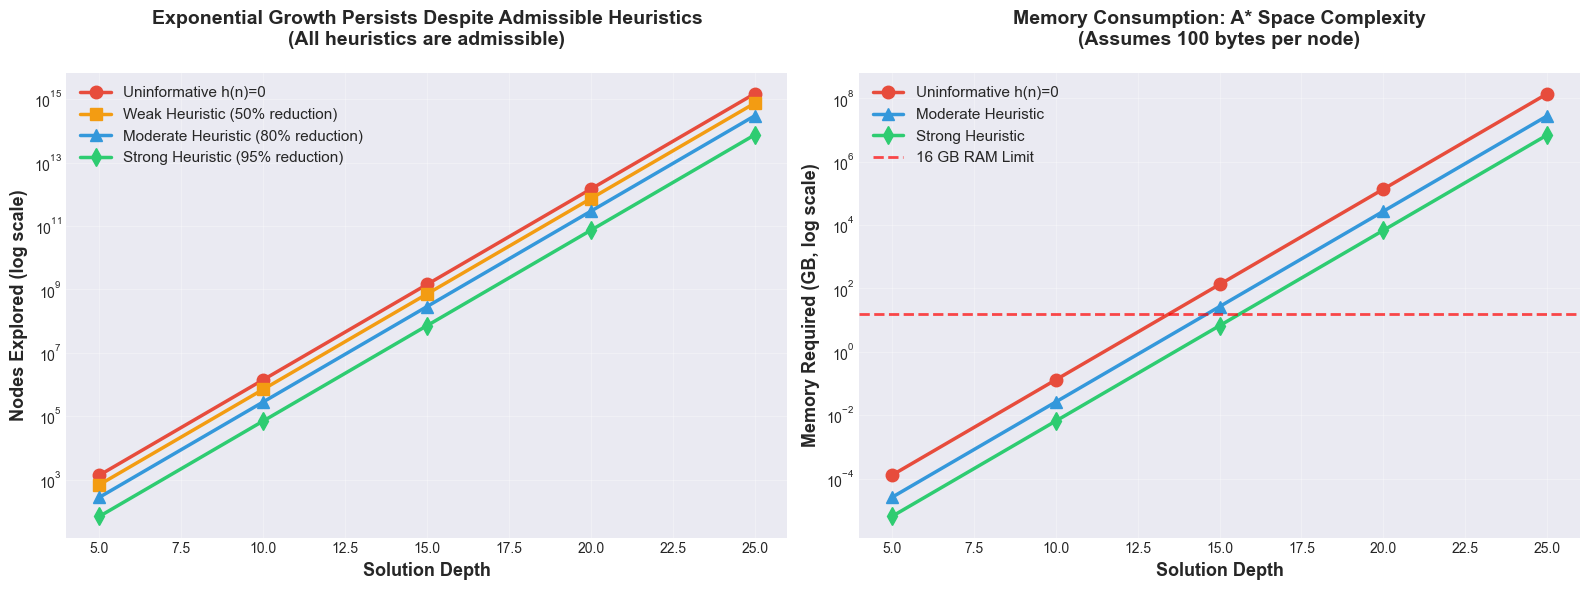

✓ Visualization complete: Exponential behavior analysis



In [100]:
# Analysis: Why A* can still exhibit exponential behavior

output = f"""
{'='*90}
QUESTION 3d: EXPONENTIAL BEHAVIOR IN A* DESPITE ADMISSIBLE HEURISTICS
{'='*90}

Even with an admissible heuristic, A* can approach exponential complexity due to:

1. Admissibility ≠ Informativeness:
   • h(n) ≤ h*(n) doesn't guarantee strong guidance toward goal
   • h(n) = 0 is admissible but uninformative (reduces A* to uniform-cost search)
   • Moderately informative heuristics leave large regions with similar f-values

2. The f* Contour Effect:
   • A* must expand ALL nodes with f(n) < f* (optimal solution cost)
   • With weak heuristics, exponentially many nodes satisfy f(n) ≤ f*
   • Example: Grid with b=4, d=20, 90% reduction still explores 0.1×4^20 ≈ 100B nodes

3. Exponential Space Complexity:
   • A* maintains ALL generated nodes in memory (open + closed lists)
   • Space O(b^d) often limits before time does
   • Memory exhaustion typically occurs before runtime becomes impractical

4. Heuristic Quality Variance:
   • Real-world heuristics vary across state space regions
   • Performance dominated by weakest regions requiring exponential exploration

Research Solutions:
   • IDA*: Trades time for space with O(d) complexity
   • SMA*, RBFS: Memory-bounded variants
   • Better heuristics: Small h(n) improvements yield exponential gains
   • Pattern databases: Pre-computed lookup tables
{'='*90}
"""
print(output)

# Quantitative demonstration of exponential growth
output_quant = f"""
QUANTITATIVE EXAMPLE: Exponential Growth Despite Admissibility
{'='*90}

Nodes Explored by A* with Different Admissible Heuristics (b=4)
"""
print(output_quant)

branching_factor = 4  # Typical grid search
solution_depth = np.arange(5, 26, 5)  # Depths from 5 to 25

# Calculate nodes explored for different heuristic qualities
# Uninformative (h=0): Pure uniform-cost search behavior
nodes_uninformative = (branching_factor**(solution_depth + 1) - 1) / (branching_factor - 1)

# Weak heuristic: Eliminates only 50% of nodes
nodes_weak = nodes_uninformative * 0.5

# Moderate heuristic: Eliminates 80% of nodes
nodes_moderate = nodes_uninformative * 0.2

# Strong heuristic: Eliminates 95% of nodes
nodes_strong = nodes_uninformative * 0.05

# Create DataFrame for display
exponential_data = {
    'Depth (d)': solution_depth,
    'Uninformative h(n)=0': [f'{n:.2e}' for n in nodes_uninformative],
    'Weak Admissible h': [f'{n:.2e}' for n in nodes_weak],
    'Moderate Admissible h': [f'{n:.2e}' for n in nodes_moderate],
    'Strong Admissible h': [f'{n:.2e}' for n in nodes_strong]
}

df_exponential = pd.DataFrame(exponential_data)
display(df_exponential)  # Use display() for better Jupyter rendering
print("\nNote: All heuristics are admissible, yet all exhibit exponential growth!")
print("      The quality (informativeness) determines the exponential base.\n")

# Visualization of exponential behavior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Exponential growth across heuristic qualities
ax1.semilogy(solution_depth, nodes_uninformative, 'o-', linewidth=2.5, markersize=9,
             color='#e74c3c', label='Uninformative h(n)=0')
ax1.semilogy(solution_depth, nodes_weak, 's-', linewidth=2.5, markersize=9,
             color='#f39c12', label='Weak Heuristic (50% reduction)')
ax1.semilogy(solution_depth, nodes_moderate, '^-', linewidth=2.5, markersize=9,
             color='#3498db', label='Moderate Heuristic (80% reduction)')
ax1.semilogy(solution_depth, nodes_strong, 'd-', linewidth=2.5, markersize=9,
             color='#2ecc71', label='Strong Heuristic (95% reduction)')

ax1.set_xlabel('Solution Depth', fontsize=13, fontweight='bold')
ax1.set_ylabel('Nodes Explored (log scale)', fontsize=13, fontweight='bold')
ax1.set_title('Exponential Growth Persists Despite Admissible Heuristics\n(All heuristics are admissible)',
              fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3, which='both')

# Subplot 2: Memory consumption (bytes) assuming 100 bytes per node
bytes_per_node = 100
memory_uninformative = nodes_uninformative * bytes_per_node / (1024**3)  # Convert to GB
memory_moderate = nodes_moderate * bytes_per_node / (1024**3)
memory_strong = nodes_strong * bytes_per_node / (1024**3)

ax2.semilogy(solution_depth, memory_uninformative, 'o-', linewidth=2.5, markersize=9,
             color='#e74c3c', label='Uninformative h(n)=0')
ax2.semilogy(solution_depth, memory_moderate, '^-', linewidth=2.5, markersize=9,
             color='#3498db', label='Moderate Heuristic')
ax2.semilogy(solution_depth, memory_strong, 'd-', linewidth=2.5, markersize=9,
             color='#2ecc71', label='Strong Heuristic')

# Add reference line for typical RAM limit (16 GB)
ax2.axhline(y=16, color='red', linestyle='--', linewidth=2, alpha=0.7, 
            label='16 GB RAM Limit')

ax2.set_xlabel('Solution Depth', fontsize=13, fontweight='bold')
ax2.set_ylabel('Memory Required (GB, log scale)', fontsize=13, fontweight='bold')
ax2.set_title('Memory Consumption: A* Space Complexity\n(Assumes 100 bytes per node)',
              fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('astar_exponential_behavior.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization complete: Exponential behavior analysis\n")

---
## Summary and Conclusions

This activity explored the critical transition in artificial intelligence from exact optimization algorithms that guarantee globally optimal solutions to heuristic search methods that provide intelligent, timely decisions under real-world constraints. Through analysis of GPS navigation systems, we demonstrated why time constraints force abandonment of optimality guarantees in favor of near-optimal solutions that remain relevant in dynamic environments. The examination of Greedy Best-First Search revealed how priority queue operations and branching factors dominate algorithm complexity, while the greedy strategy's exclusive focus on heuristic values trades completeness and optimality for significant computational speedup.

The detailed tracing of A* search on the provided graph illustrated how the algorithm balances actual path cost g(n) with heuristic estimates h(n) to achieve optimal solutions more efficiently than uninformed search. Comparing A* expansion order to Greedy Best-First Search highlighted A*'s fundamental advantage: consideration of accumulated costs prevents premature commitment to apparently promising paths that have actually become expensive. The admissibility analysis demonstrated that overestimating heuristics create repulsive fields around nodes, severely disrupting exploration patterns and destroying optimality guarantees.

Finally, the investigation of A*'s potential for exponential behavior emphasized that admissibility alone does not ensure efficiency—heuristic informativeness determines the practical size of the search space. Even with perfect admissibility, weak heuristics leave A* exploring exponentially many nodes within the optimal solution cost contour, with memory requirements typically becoming the limiting factor before runtime in large-scale problems.

These analyses reinforce the core lesson of Module 4: intelligent AI systems must navigate the tension between solution quality and computational practicality, employing heuristics not as approximations to be tolerated but as essential tools enabling real-time decision-making in complex, dynamic environments.

---
## References

Blauth, J., Held, S., Müller, D., Schlomberg, N., Traub, V., Tröbst, T., & Vygen, J. (2022). Vehicle routing with time-dependent travel times: Theory, practice, and benchmarks (arXiv:2205.00889). arXiv. 
https://arxiv.org/pdf/2205.00889

Braga, M. de L., Nunes, B. A. A., Viana, A. C., Cunha, F. D., & Ghamri-Doudane, Y. (2016). Anytime route planning with constrained devices. Computers & Electrical Engineering, 54, 53–67. https://www.sciencedirect.com/science/article/abs/pii/S0045790616301835

Chen, M.-C. (2026). *Module 4 - Lecture 4A: From exact optimization to intelligent decision-making* [Lecture notes]. EN.705.623.81 AI Algorithm Design and Analysis, Johns Hopkins University. Retrieved from https://jhu.edu

Chen, M.-C. (2026). *Module 4 - Lecture 4B: Greedy search* [PDF slides]. EN.705.623.81 AI Algorithm Design and Analysis, Johns Hopkins University. Retrieved from https://jhu.edu

Chen, M.-C. (2026). *Module 4 - Lecture 4C: A* search* [Lecture materials]. EN.705.623.81 AI Algorithm Design and Analysis, Johns Hopkins University. Retrieved from https://jhu.edu

Ferguson, D., Likhachev, M., & Stentz, A. (2005). A guide to heuristic-based path planning. In Proceedings of the ICAPS 2005 Workshop on Planning under Uncertainty for Autonomous Systems (pp. 9–18). AAAI Press. https://www.cs.cmu.edu/~maxim/files/hsplanguide_icaps05ws.pdf

Hart, P. E., Nilsson, N. J., & Raphael, B. (1968). A formal basis for the heuristic determination of minimum cost paths. *IEEE Transactions on Systems Science and Cybernetics, 4*(2), 100-107. https://doi.org/10.1109/TSSC.1968.300136

Li, H., & Kim, S. (2024). Efficient route planning for real-time demand-responsive transit. Computers, Materials & Continua, 79(1), 474–489. https://doi.org/10.32604/cmc.2024.048402

Metz, D. (2022). The impact of digital navigation on travel behaviour. UCL Open: Environment, 4, Article 1063. https://journals.uclpress.co.uk/ucloe/article/id/1063/

Pearl, J. (1984). *Heuristics: Intelligent search strategies for computer problem solving*. Addison-Wesley. https://dl.acm.org/doi/10.5555/525

Russell, S., & Norvig, P. (2021). *Artificial intelligence: A modern approach* (4th ed.). Pearson. http://aima.cs.berkeley.edu/

Song, X., Yang, Z., Wang, T., Li, C., Zhang, Y., & Chen, G. (2021). Dynamic traffic assignment model based on GPS data and point of interest (POI) in Shanghai. Sensors, 21(21), 7341. https://doi.org/10.3390/s21217341

Strasser, B., & Zeitz, T. (2021). A fast and tight heuristic for A* in road networks* (arXiv:1910.12526). arXiv. https://arxiv.org/abs/1910.12526

Ugwoke, K. C., Nnanna, N. A., & Abdullahi, S. E. (2025). Simulation-based review of classical, heuristic, and metaheuristic path planning algorithms. Scientific Reports, 15, 12643. https://doi.org/10.1038/s41598-025-96614-2